# Stage 2 — Look at the data

**The question:** what does this dataset actually look like, and what is going to
break a tissue detector?

Stage 1 counted things. This stage looks at things. In Stage 5 we have to pick
colour thresholds that separate tissue from empty glass, and the rule for this
project is that those numbers get chosen because we *saw* the pictures, never
because a document suggested a value.

Two different questions get asked here, and they need different tools:

- **"Does this problem exist?"** — answerable by looking at a few dozen slides.
  Eyes are reliable at spotting that something exists.
- **"On how many slides?"** — *not* answerable by looking. Seeing pen ink on 5
  of 20 slides is consistent with anywhere between 11% and 47% of the dataset.
  Writing down "about 25%" would be inventing a fact.

So this notebook does two things. First it builds a **thumbnail cache** — one
small picture of every one of the 10,616 slides, saved to disk. Then it uses
that cache to browse the dataset *ranked* by different measurements, so that
counting means sorting all 10,616 slides and looking at where the real cases
stop, rather than extrapolating from a handful.

In [1]:
"""Imports.

glob       finds files by pattern; used on Kaggle to locate the outputs of
           earlier notebooks, which arrive as attached datasets.
math       rounds grid sizes up (math.ceil) when laying out thumbnails.
os         builds file paths and checks whether a file exists on disk.
cv2        (OpenCV) converts thumbnails from RGB to HSV colour.
numpy      holds the thumbnails as arrays and does all the per-slide sums.
openslide  opens the whole-slide .tiff files.
pandas     loads the Stage 1 inventory and saves the colour statistics.
matplotlib draws the thumbnail grids.
PIL        (Image) builds the white square each thumbnail is centred on.
tqdm       draws progress bars for the two long passes over every slide.
"""

import glob
import math
import os

import cv2
import numpy as np
import openslide
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [2]:
"""Paths and settings.

Where things are read from
--------------------------
1. ON_KAGGLE is True inside a Kaggle notebook, where /kaggle/input exists.
2. DATA_DIR holds the competition data. Kaggle mounts it read-only under
   /kaggle/input; locally it is ../data.
3. IMAGE_DIR holds the slide images, one {slide_id}.tiff per slide.
4. find_input(filename) locates a file made by an earlier notebook. It looks
   in DERIVED_DIR first. On Kaggle every notebook runs separately, so an
   earlier notebook's output usually arrives as an attached dataset instead;
   in that case it searches every attached dataset, both at the top level and
   inside a derived/ folder. It prints where it found the file, and stops with
   a clear error if the file is nowhere.
5. INVENTORY_PATH is the Stage 1 inventory, found with find_input.

Where things are written to
---------------------------
6. DERIVED_DIR is where this project writes its own files. On Kaggle it is
   /kaggle/working/derived/, because /kaggle/input is read-only.
7. CACHE_DIR holds the thumbnail cache. It sits in its own folder because it
   is rebuildable bulk data, not a result: it can be deleted at any time and
   regenerated by re-running this notebook.
8. THUMB_ARRAY_PATH is the cache itself: one square picture per slide, all
   the same size, stored as a single array on disk.
9. THUMB_IDS_PATH lists which slide each row of that array belongs to.
10. COLOUR_STATS_PATH is the per-slide colour table this notebook produces.
    Notebooks 4 and 5 read it, so its name and columns must not change.

Settings
--------
11. THUMB_BOX is the side length of each thumbnail in pixels. 256 is big enough
    to see pen marks and staining differences, and small enough that the
    whole cache is about 2 GB: 10,616 slides x 256 x 256 pixels x 3 colour
    channels x 1 byte.
12. SEED fixes which slides the random samples pick, so "the 20 slides we
    looked at" is the same set every time. Without it, re-running shows
    different slides and any note about a particular one becomes meaningless.
"""

ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    DATA_DIR = "/kaggle/input/prostate-cancer-grade-assessment/"
    DERIVED_DIR = "/kaggle/working/derived/"
else:
    DATA_DIR = "../data/"
    DERIVED_DIR = os.path.join(DATA_DIR, "derived/")

IMAGE_DIR = os.path.join(DATA_DIR, "train_images/")


def find_input(filename):
    """Return the path of a file made by an earlier notebook."""
    candidates = [os.path.join(DERIVED_DIR, filename)]
    if ON_KAGGLE:
        candidates += sorted(glob.glob(os.path.join("/kaggle/input", "*", filename)))
        candidates += sorted(glob.glob(os.path.join("/kaggle/input", "*", "derived", filename)))
    for path in candidates:
        if os.path.exists(path):
            print(f"{filename}: {path}")
            return path
    raise FileNotFoundError(
        f"{filename} not found; run the notebook that makes it, " f"or attach its output as a dataset on Kaggle"
    )


INVENTORY_PATH = find_input("slide_inventory.parquet")

CACHE_DIR = os.path.join(DERIVED_DIR, "cache/")
THUMB_ARRAY_PATH = os.path.join(CACHE_DIR, "thumbnails_256.npy")
THUMB_IDS_PATH = os.path.join(CACHE_DIR, "thumbnails_256_ids.npy")
COLOUR_STATS_PATH = os.path.join(DERIVED_DIR, "slide_colour_stats.parquet")

THUMB_BOX = 256
SEED = 0

slide_inventory.parquet: ../data/derived/slide_inventory.parquet


In [3]:
"""Load the Stage 1 inventory and add the size columns used below.

1. Read the inventory: one row per slide, made by notebook 1.
2. Stage 1 stored each slide's level-0 size as a (width, height) pair. Sorting
   and comparing are easier on plain numbers, so the pair is split into two
   columns, level0_w and level0_h.
3. area_mpx is the level-0 area in megapixels, width times height divided by
   one million. It ranks slides by physical size in section 2c.
4. Print the table's shape and show the first rows as a check.
"""

slide_inventory = pd.read_parquet(INVENTORY_PATH)

slide_inventory["level0_w"] = slide_inventory["tiff_lvl0_dim"].apply(lambda d: int(d[0]))
slide_inventory["level0_h"] = slide_inventory["tiff_lvl0_dim"].apply(lambda d: int(d[1]))
slide_inventory["area_mpx"] = slide_inventory["level0_w"] * slide_inventory["level0_h"] / 1e6

print(slide_inventory.shape)
slide_inventory.head()

(10616, 16)


,slide_id,gleason_score,isup_grade,provider,slide_exists,mask_exists,feature_file_exists,feature_tile_count,tiff_pym_lvls,tiff_lvl0_dim,tiff_lvl_ds,tiff_mpx,percentage_empty,level0_w,level0_h,area_mpx
0,0005f7aaab2800f6170c399693a96917,0+0,0,karolinska,True,True,None,None,3,"[27648, 29440]","[1.0, 4.0, 16.0]","[0.45201826153776614, 0.45201826153776614]",96.895192,27648,29440,813.957120
1,000920ad0b612851f8e01bcc880d9b3d,0+0,0,karolinska,True,True,None,None,3,"[15360, 13312]","[1.0, 4.0, 16.0]","[0.45201826153776614, 0.45201826153776614]",94.424705,15360,13312,204.472320
2,0018ae58b01bdadc8e347995b69f99aa,4+4,4,radboud,True,True,None,None,3,"[5888, 25344]","[1.0, 4.0, 16.0]","[0.4861876369654638, 0.4861876369654638]",82.860363,5888,25344,149.225472
3,001c62abd11fa4b57bf7a6c603a11bb9,4+4,4,karolinska,True,True,None,None,3,"[23904, 28664]","[1.0, 4.0, 16.00223338916806]","[0.5031982437947761, 0.5031982437947761]",95.209238,23904,28664,685.184256
4,001d865e65ef5d2579c190a0e0350d8f,0+0,0,karolinska,True,True,None,None,3,"[28672, 34560]","[1.0, 4.0, 16.0]","[0.45201826153776614, 0.45201826153776614]",94.389209,28672,34560,990.904320


## 1. Build the thumbnail cache

A whole-slide image is stored as a pyramid: the same picture saved several
times at different sizes inside one file. The smallest level of a PANDA slide
is a few hundred to a couple of thousand pixels across, which is small enough
to load instantly — but *finding* and decoding it still costs about 60
milliseconds per slide, so a pass over the whole dataset takes roughly ten
minutes.

Ten minutes is fine once. It is not fine every time we want to ask a new
question. So we do that pass a single time and save the result.

Three details worth understanding:

**Why square, and why padded.** Biopsy slides are long thin needles, often ten
times taller than they are wide, and every slide has a different shape. If we
stored them at their natural shapes we could not put them in one array, and a
grid of them would not line up. So each thumbnail is shrunk to fit inside a
256x256 box, keeping its proportions, and then centred on a white square. White,
because the empty part of a glass slide is white under a scanner — padding with
black would invent dark content that isn't there.

**Why one big file instead of 10,616 small ones.** Opening a file is a request
to the operating system and costs far more than reading a few bytes. One array
opens once. NumPy can also *memory-map* it, meaning the file is read from disk
only as we touch parts of it, so loading is instant no matter how big it is.

**Why we save the slide ids alongside.** Row 4,213 of the array is meaningless
unless we know which slide it is. The ids are saved in the same order, and the
loader below checks that they still match the inventory.

In [4]:
"""Build the thumbnail cache, or reuse it if it already exists.

Two functions: slide_thumbnail makes one thumbnail, build_thumbnail_cache makes
all of them and writes them to disk. The last line runs the build. It takes
about ten minutes the first time, and returns straight away once a complete
cache exists.
"""


def slide_thumbnail(slide_id, box=THUMB_BOX):
    """Read one slide at small size and return it as a padded white square.

    1. Open the slide's .tiff.
    2. get_thumbnail() takes a bounding box, not an exact size: it picks the
       cheapest pyramid level to read, then shrinks the picture until it fits
       inside the box while keeping its proportions. It also fills transparent
       areas with the slide's background colour, white, which read_region()
       would otherwise leave black.
    3. The slide is closed in a finally block, so it is closed even if the read
       fails. A loop over 10,616 slides that leaves files open would use up the
       operating system's limit on open files partway through.
    4. Make a white square box pixels across and paste the thumbnail in its
       centre. White, because empty glass is white under a scanner; padding
       with black would invent dark content that is not there.
    5. Return the square as an array of shape (box, box, 3).
    """
    slide = openslide.OpenSlide(os.path.join(IMAGE_DIR, f"{slide_id}.tiff"))
    try:
        thumbnail = slide.get_thumbnail((box, box))
    finally:
        slide.close()

    canvas = Image.new("RGB", (box, box), (255, 255, 255))
    canvas.paste(thumbnail, ((box - thumbnail.width) // 2, (box - thumbnail.height) // 2))
    return np.asarray(canvas)


def build_thumbnail_cache(slide_ids, box=THUMB_BOX, rebuild=False):
    """Write one padded square thumbnail per slide into a single array on disk.

    1. If both cache files already exist and the array has one row per slide,
       stop: there is nothing to do. rebuild=True forces a fresh build.
    2. Create the cache folder if needed.
    3. open_memmap creates the array file on disk up front, at its full size,
       and returns something that can be filled in like an ordinary array. The
       2 GB is written to disk as it is filled and never has to fit in memory.
    4. Fill row i with slide i's thumbnail. If one slide cannot be read, note
       it and move on, so one bad file cannot end a ten-minute loop; its row
       stays all zeros, i.e. black.
    5. flush() makes sure everything has reached the disk.
    6. Save the slide ids in the same order, so row i can always be matched
       back to its slide.
    7. Report how many were written and list any that failed.
    """
    slide_ids = list(slide_ids)

    if os.path.exists(THUMB_ARRAY_PATH) and os.path.exists(THUMB_IDS_PATH) and not rebuild:
        existing = np.load(THUMB_ARRAY_PATH, mmap_mode="r")
        if existing.shape == (len(slide_ids), box, box, 3):
            print(f"cache already exists: {existing.shape}")
            return
        print(f"cache has wrong shape {existing.shape}, rebuilding")

    os.makedirs(CACHE_DIR, exist_ok=True)

    cache = np.lib.format.open_memmap(THUMB_ARRAY_PATH, mode="w+", dtype=np.uint8, shape=(len(slide_ids), box, box, 3))

    failed = []
    for i, slide_id in enumerate(tqdm(slide_ids, desc="thumbnails")):
        try:
            cache[i] = slide_thumbnail(slide_id, box)
        except Exception as error:
            failed.append((slide_id, str(error)))

    cache.flush()
    np.save(THUMB_IDS_PATH, np.array(slide_ids))

    print(f"wrote {len(slide_ids)} thumbnails, {len(failed)} failed")
    if failed:
        print(failed[:10])


build_thumbnail_cache(slide_inventory["slide_id"])

cache already exists: (10616, 256, 256, 3)


In [5]:
"""Open the cache and check it matches the inventory.

1. mmap_mode="r" opens the array without reading it. Rows are read from disk
   only when they are used, so this line is instant even though the file is
   2 GB.
2. Load the list of slide ids, in the same order as the array's rows.
3. The array only means anything if row i really is slide i of the inventory.
   The assert checks that instead of assuming it: a mismatch would silently
   attach every picture to the wrong slide, and nothing later would complain.
4. row_of_slide maps a slide id to its row, so a thumbnail can be looked up by
   id.
5. Print the array's shape, type and size on disk.
"""

thumbnails = np.load(THUMB_ARRAY_PATH, mmap_mode="r")
thumbnail_ids = np.load(THUMB_IDS_PATH, allow_pickle=True)

assert list(thumbnail_ids) == list(slide_inventory["slide_id"]), "cache is out of sync with the inventory"

row_of_slide = {slide_id: i for i, slide_id in enumerate(thumbnail_ids)}

print(thumbnails.shape, thumbnails.dtype, f"{thumbnails.nbytes / 1e9:.2f} GB on disk")

(10616, 256, 256, 3) uint8 2.09 GB on disk


## 2. Looking at slides

Everything below reads from the cache, so each grid appears in well under a
second. That speed is the point: it is what makes it reasonable to look at the
extremes of several different rankings instead of one random sample.

In [6]:
"""Two helpers used by every section below: one draws grids, one samples."""


def show_grid(rows, ncols=5, suptitle=None, label=None):
    """Draw a grid of cached thumbnails, one per row of an inventory slice.

    rows:  a slice of slide_inventory rather than a list of ids, so that each
           picture can be captioned with that slide's grade, hospital and
           measurements.
    label: a function taking one row and returning its caption. Without one,
           the caption is the slide id, grade and hospital.

    1. Work out how many grid rows are needed, rounding up.
    2. subplots() returns a single panel for a 1x1 grid and a flat list for a
       single row, so np.atleast_1d(...).ravel() turns every case into one flat
       list of panels.
    3. Turn off every panel's frame first, including the empty panels at the
       end of a partly filled last row, which would otherwise show empty boxes.
    4. Draw each thumbnail, looked up by slide id, with its caption.
    5. Add the overall title and tidy the spacing.
    """
    if label is None:

        def label(row):
            return f"{row.slide_id[:8]}\nISUP {row.isup_grade}  {row.provider[:4]}"

    rows = list(rows.itertuples())
    nrows = math.ceil(len(rows) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 2.7))
    axes = np.atleast_1d(axes).ravel()

    for ax in axes:
        ax.set_axis_off()

    for ax, row in zip(axes, rows):
        ax.imshow(thumbnails[row_of_slide[row.slide_id]])
        ax.set_title(label(row), fontsize=7)

    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    return fig


def sample_rows(rows, n, seed=SEED):
    """A repeatable random sample of n rows, or every row if there are fewer."""
    return rows.sample(min(n, len(rows)), random_state=seed)

### 2a. The two hospitals, side by side

Radboud and Karolinska used different scanners and different staining
protocols, so their slides do not look alike. Stage 1 established that they
scan at the same physical resolution, which rules magnification out — but
colour is a separate matter, and a saturation threshold tuned on one hospital
may fail on the other. Look for how different the pinks and purples are.

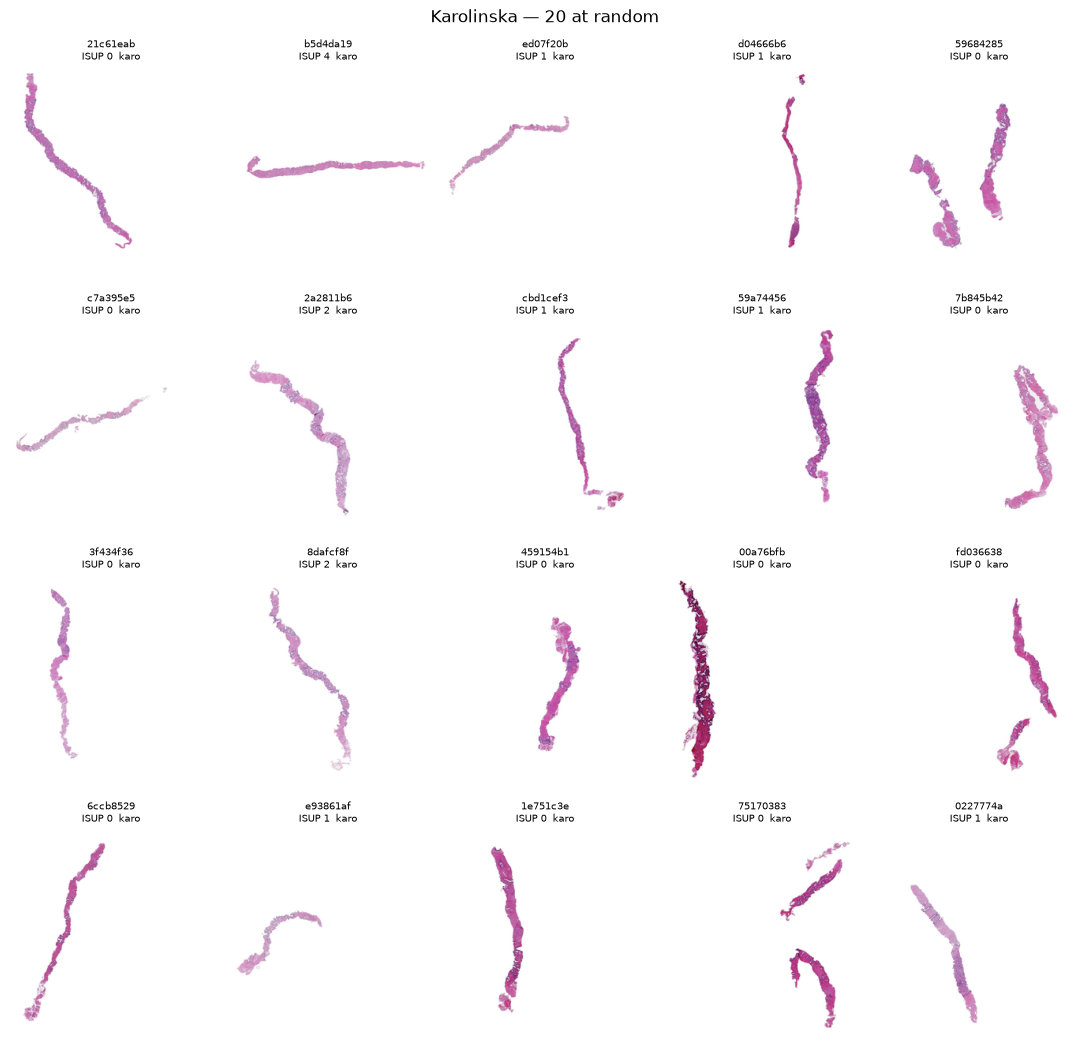

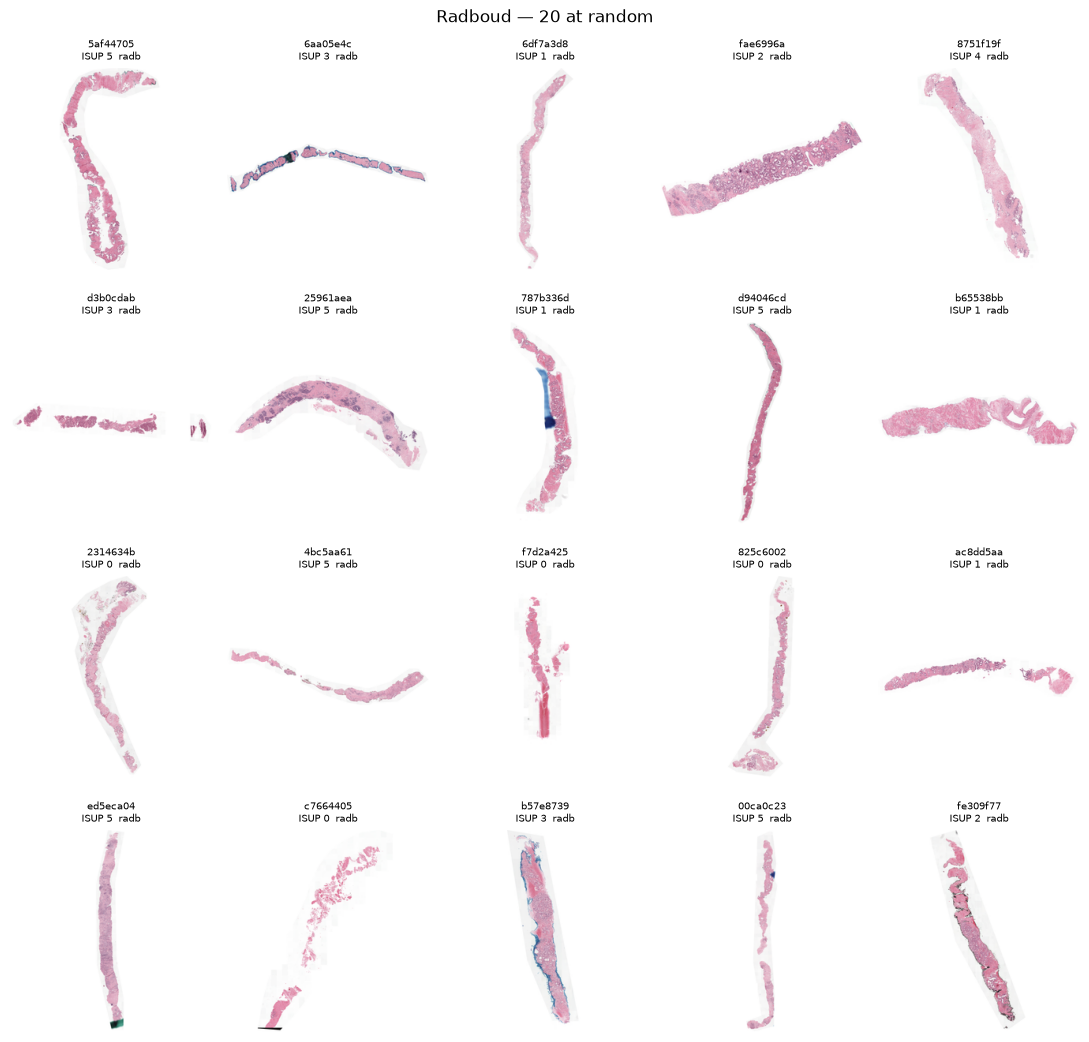

In [7]:
"""Twenty random slides from each hospital, drawn as two separate grids so the
difference in colour between the two is easy to compare."""

karolinska = sample_rows(slide_inventory[slide_inventory["provider"] == "karolinska"], 20)
radboud = sample_rows(slide_inventory[slide_inventory["provider"] == "radboud"], 20)

show_grid(karolinska, suptitle="Karolinska — 20 at random")
show_grid(radboud, suptitle="Radboud — 20 at random")
plt.show()

### 2b. Ten slides from each grade

Grade 0 means no cancer; grade 5 is the most aggressive. At this zoom level the
difference is mostly invisible — the pattern that defines a Gleason grade lives
at cell scale, thousands of times smaller than one pixel here. That is worth
seeing for yourself, because it is the reason the whole pipeline exists: the
grade cannot be read off a thumbnail, so we have to cut the slide into tiles
and look at them properly.

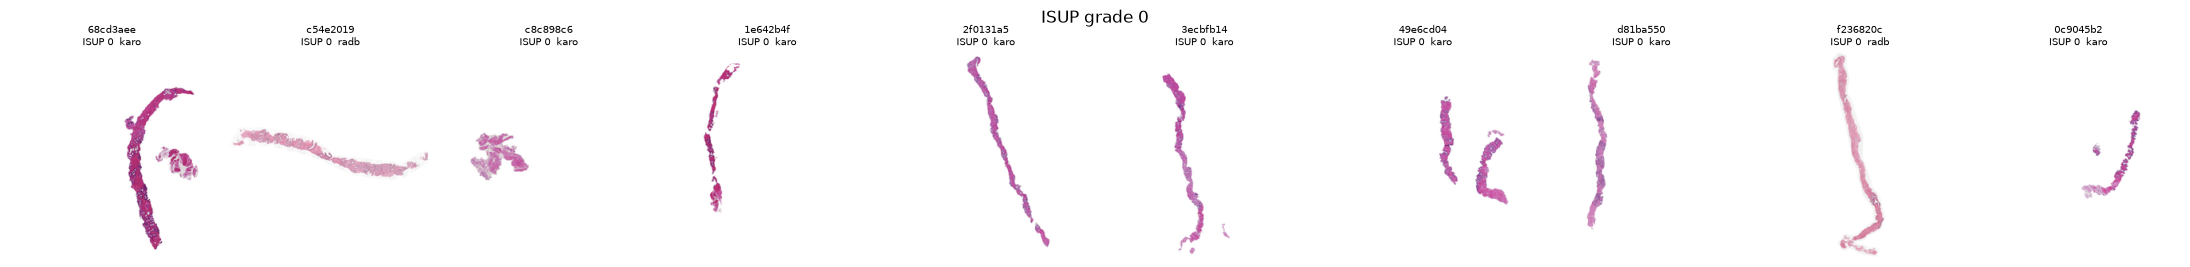

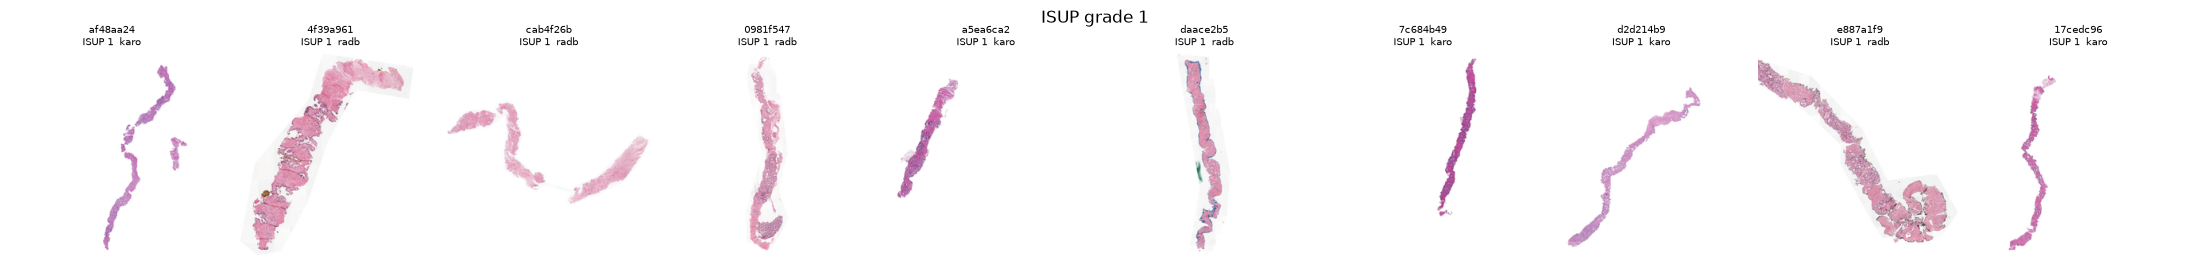

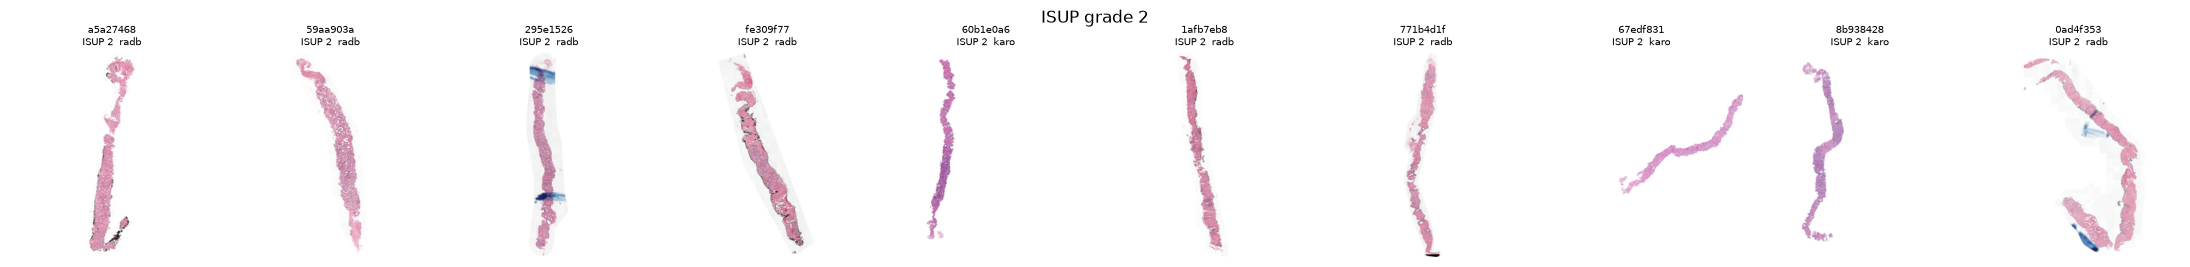

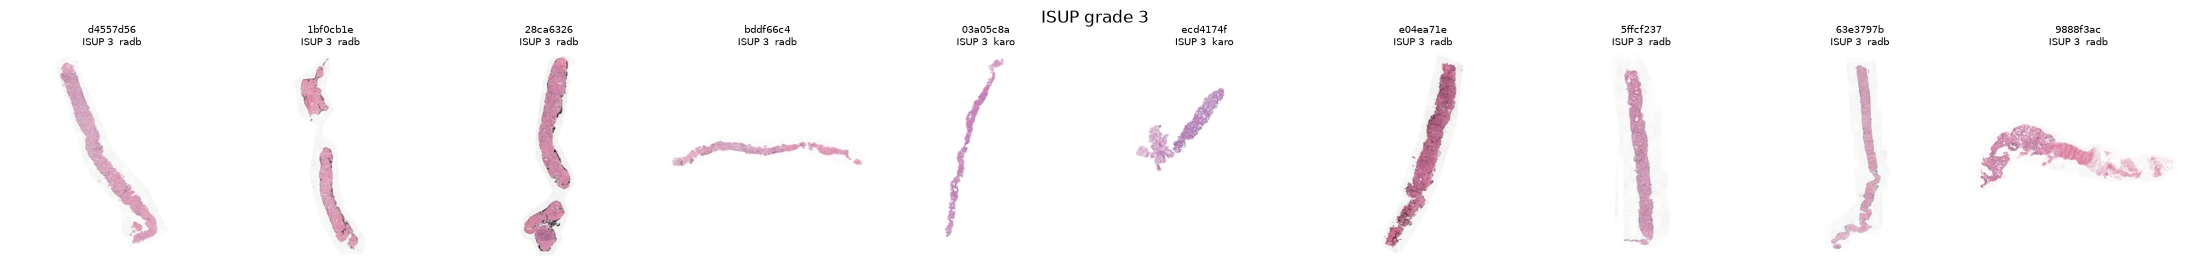

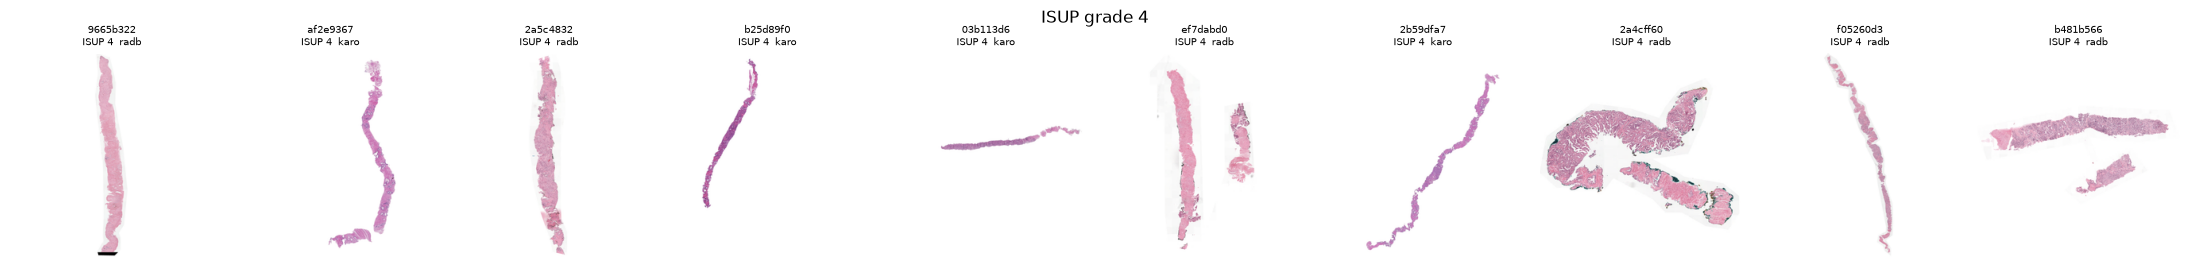

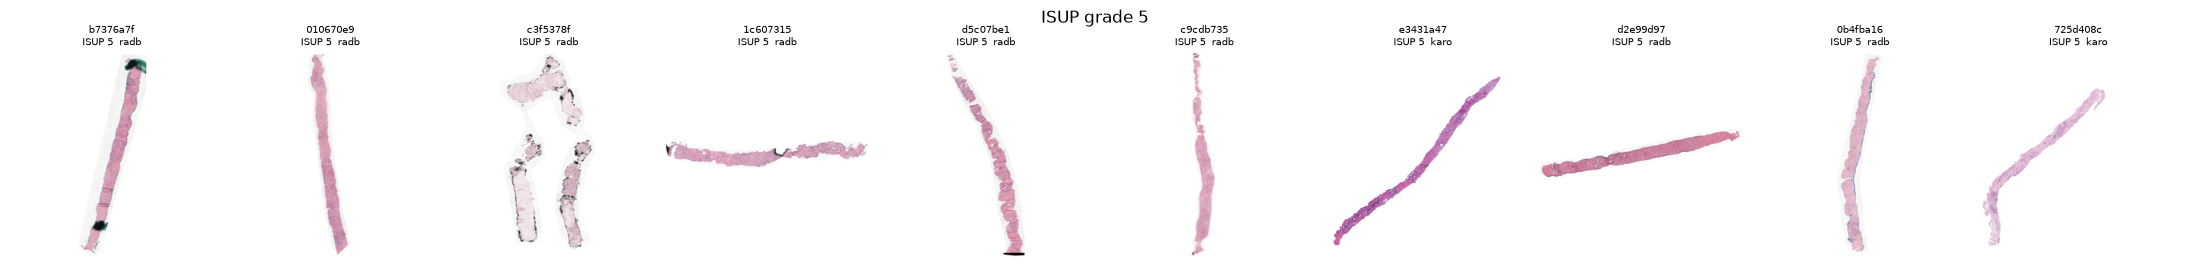

In [8]:
"""Ten random slides for each ISUP grade, 0 to 5, one grid per grade."""

for grade in range(6):
    rows = sample_rows(slide_inventory[slide_inventory["isup_grade"] == grade], 10)
    show_grid(rows, ncols=10, suptitle=f"ISUP grade {grade}")
plt.show()

### 2c. The extremes

Random samples show you the typical case, which is the case that will work
anyway. The failures live at the ends of the distribution, so those are what we
actually need to look at.

`percentage_empty` comes from Stage 1: the share of each slide that is nearly
white, measured on the smallest pyramid level. High means there is very little
tissue on the glass. Those slides are the ones a tissue detector will struggle
with, and they set the limit on how aggressive its threshold can be.

Compare within a hospital, not across — Karolinska's slides are about four and
a half times larger in area, so the same amount of tissue looks emptier there.

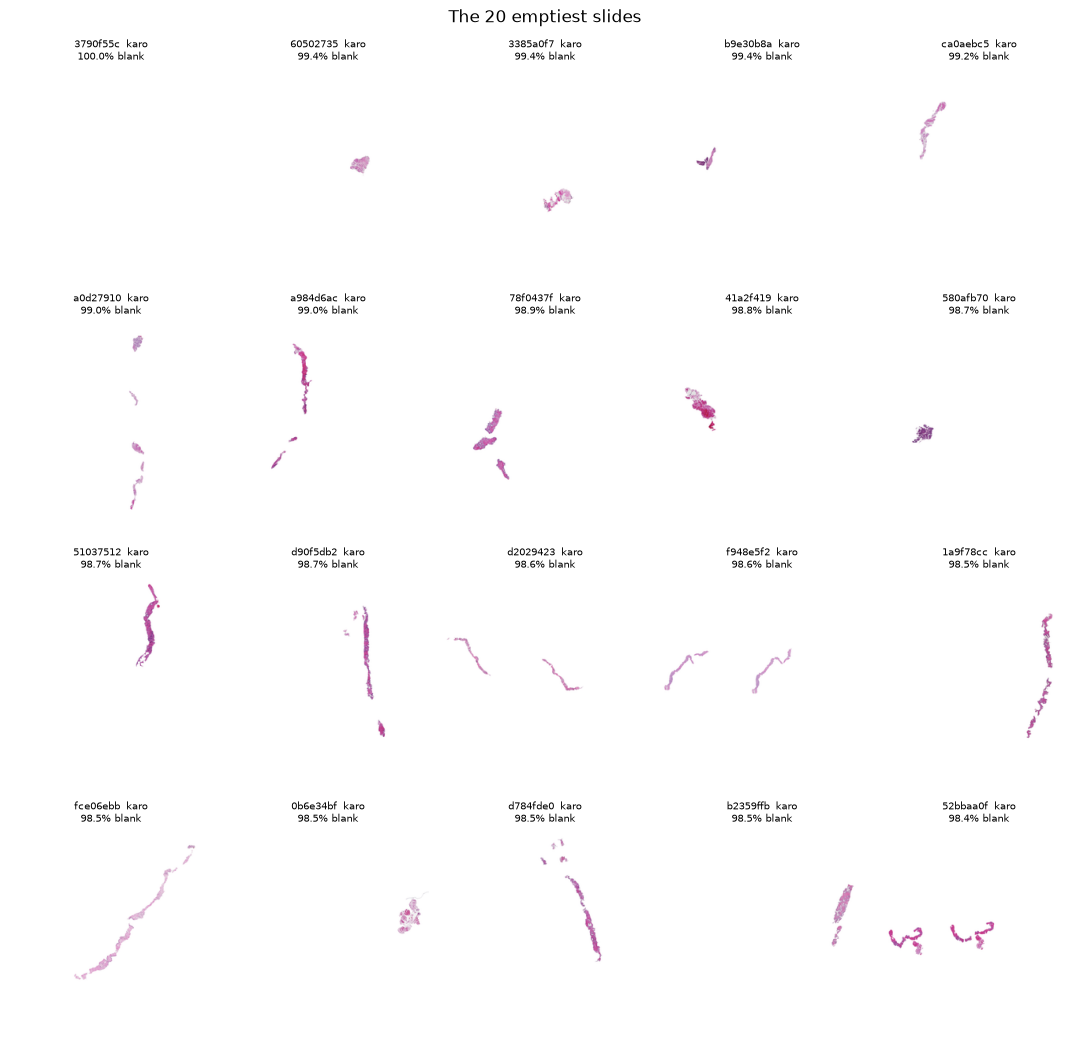

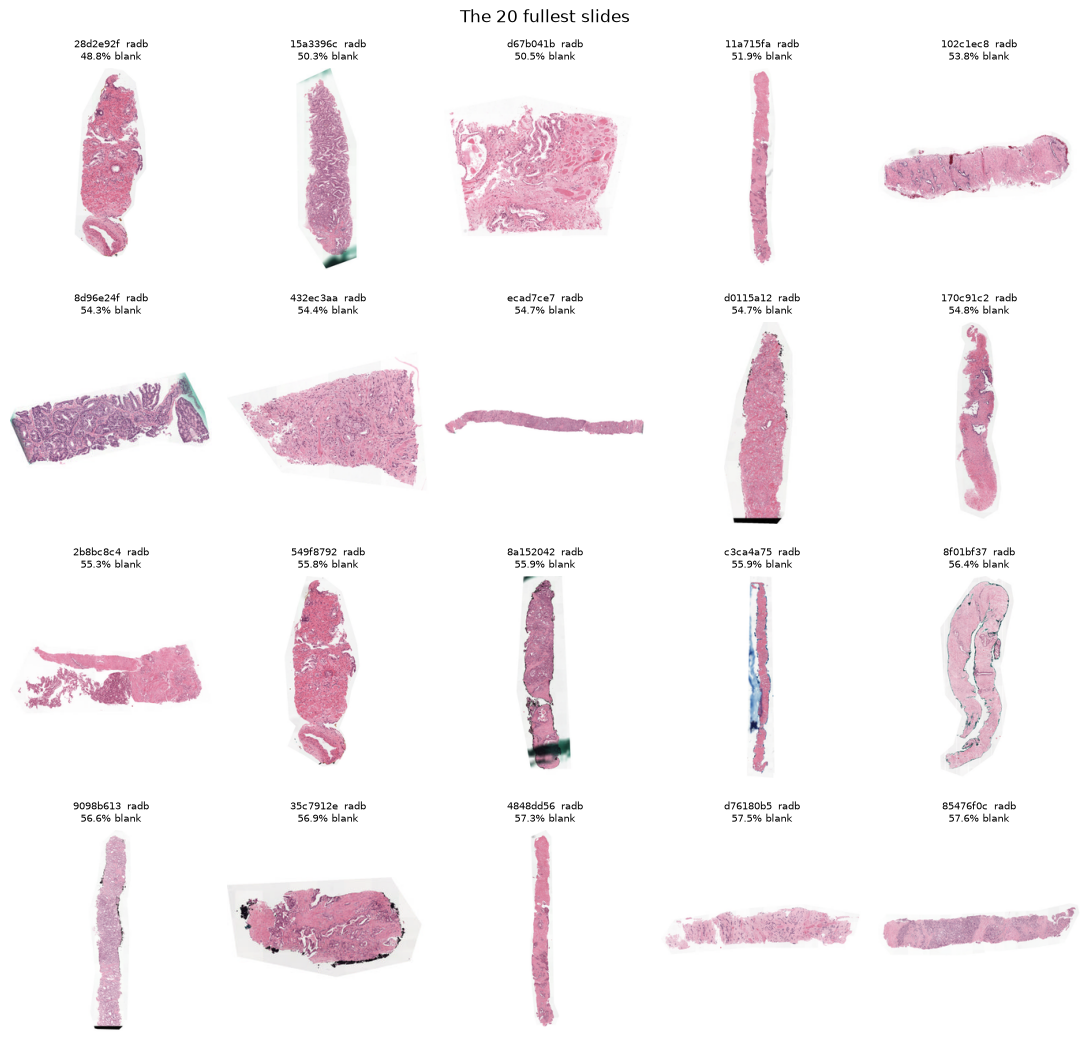

In [9]:
"""The 20 emptiest and the 20 fullest slides by Stage 1's percentage_empty.

nlargest and nsmallest sort by the column and keep the top or bottom rows.
Each caption shows the slide's percentage of near-white glass.
"""

emptiest = slide_inventory.nlargest(20, "percentage_empty")
show_grid(
    emptiest,
    suptitle="The 20 emptiest slides",
    label=lambda r: f"{r.slide_id[:8]}  {r.provider[:4]}\n{r.percentage_empty:.1f}% blank",
)

fullest = slide_inventory.nsmallest(20, "percentage_empty")
show_grid(
    fullest,
    suptitle="The 20 fullest slides",
    label=lambda r: f"{r.slide_id[:8]}  {r.provider[:4]}\n{r.percentage_empty:.1f}% blank",
)
plt.show()

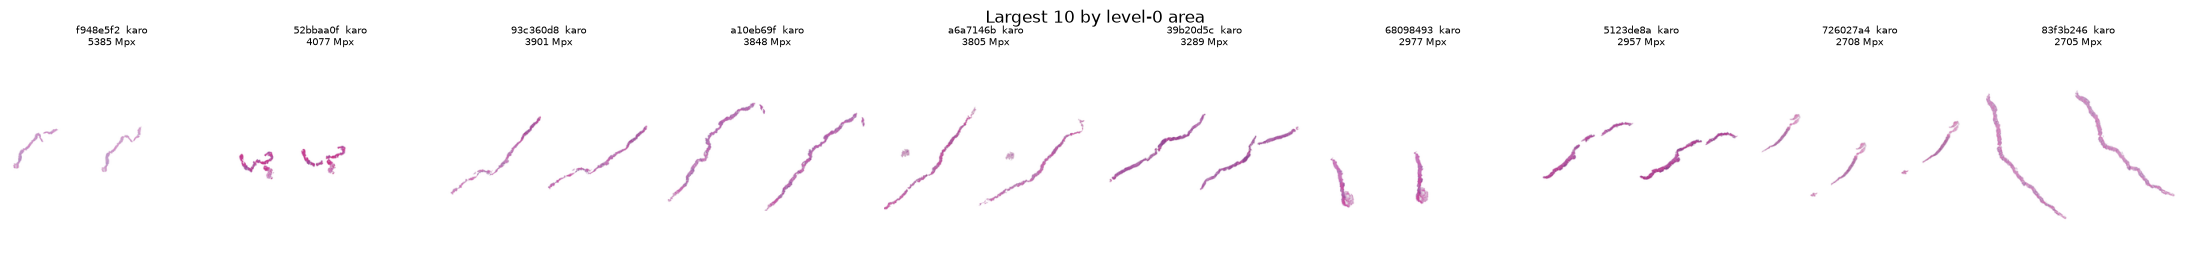

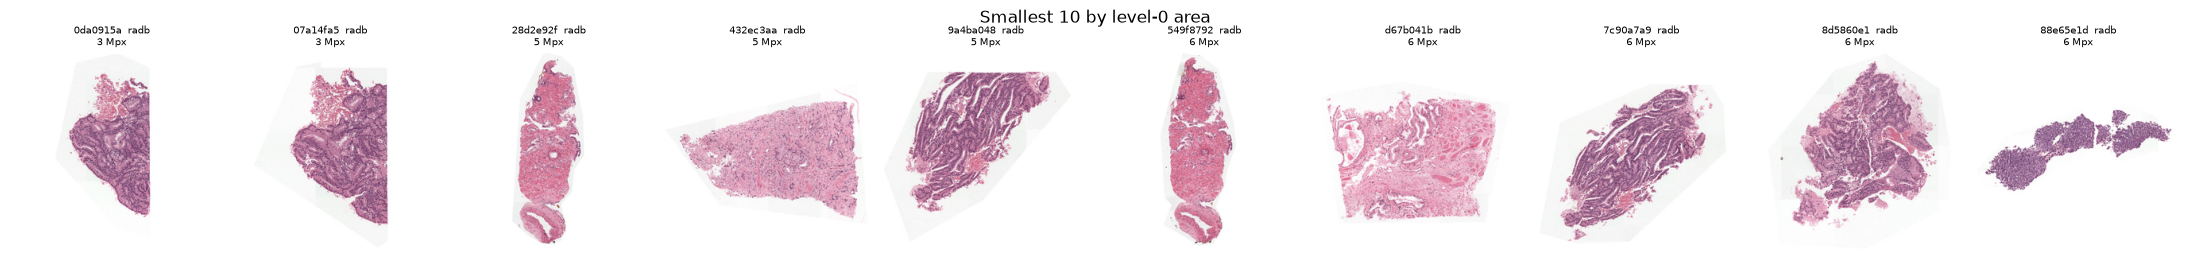

In [10]:
"""The 10 largest and the 10 smallest slides by level-0 area.

Physical size is a different question from emptiness: a slide can be enormous
and nearly blank, or tiny and full. Both ends are worth a look, because tiling
has to cope with a slide barely bigger than a few tiles as well as one that is
hundreds of times bigger. Each caption shows the area in megapixels.
"""

largest = slide_inventory.nlargest(10, "area_mpx")
smallest = slide_inventory.nsmallest(10, "area_mpx")

show_grid(
    largest,
    ncols=10,
    suptitle="Largest 10 by level-0 area",
    label=lambda r: f"{r.slide_id[:8]}  {r.provider[:4]}\n{r.area_mpx:.0f} Mpx",
)
show_grid(
    smallest,
    ncols=10,
    suptitle="Smallest 10 by level-0 area",
    label=lambda r: f"{r.slide_id[:8]}  {r.provider[:4]}\n{r.area_mpx:.0f} Mpx",
)
plt.show()

## 3. Measuring colour across all 10,616 slides

Now the counting half.

To rank slides by anything to do with colour we need numbers, and RGB is a poor
place to get them. RGB describes a colour as amounts of red, green and blue,
which is how screens work but not how "is this pink tissue or blue ink?"
works — pale pink and dark purple are both tissue but have very different RGB
values.

**HSV** describes the same colour in three more useful ways:

- **Hue** — which colour it is, going round a wheel. OpenCV squeezes the wheel
  into 0-179 rather than 0-359, so every hue number you read online needs
  halving. Green sits around 60, blue around 110, and the pink-to-purple of
  stained tissue around 140-175.
- **Saturation** — how strong the colour is, 0-255. White and grey are near 0.
- **Value** — how bright it is, 0-255. White is 255, black is 0.

That makes the two things we care about easy to express. Empty glass is bright
and colourless: high value, low saturation. Pen ink is strongly coloured but in
the *wrong* part of the wheel: high saturation, hue in the green-to-blue range
instead of the pink-to-purple range.

Nothing here is a tissue detector. These are ranking aids, used to decide which
slides are worth putting on screen. The real detector, and the thresholds it
uses, is Stage 5's job and gets chosen by looking at the pictures this stage
produces.

In [11]:
"""Measure colour on every slide, and save the results for later notebooks.

1. thumbnail_colour_stats summarises a block of thumbnails (see its own
   description below).
2. The cache is processed in blocks of CHUNK thumbnails rather than all at
   once, so the 2 GB never has to be loaded into memory.
3. The per-block results are joined into one table, stats, with one row per
   slide in cache order.
4. The cache is in inventory order, which was checked when it was opened, so
   stats lines up with the inventory row for row and the two can be placed
   side by side. Any colour columns left over from an earlier run of this cell
   are removed first, so re-running it does not create duplicate columns.
5. Save slide_id plus the four colour measurements to COLOUR_STATS_PATH.
   Notebook 4 needs the ink score to check that pen-marked slides are spread
   across folds, and notebook 5 uses the saturation to find faint slides.
   Saving them here avoids a second copy of this logic in those notebooks.
"""


def thumbnail_colour_stats(chunk):
    """Summarise a block of thumbnails. Input is [n, box, box, 3] uint8 RGB.

    1. Convert each thumbnail from RGB to HSV and stack them into one array.
       cv2 handles one image at a time, hence the loop. COLOR_RGB2HSV rather
       than BGR2HSV, because these pictures came from PIL, which stores
       channels as red-green-blue; getting it backwards swaps red and blue and
       quietly spoils every threshold below.
    2. Split out hue (which colour), saturation (how strong) and value (how
       bright).
    3. not_blank marks every pixel that is not near-white (value below 235).
       This is "not blank" rather than "tissue": it excludes the white padding
       and empty glass, but includes pen, dust and shadows on purpose, because
       those are exactly what the rankings are for.
    4. Count the not-blank pixels in each thumbnail. safe_count is the same
       count but never below 1, so a completely white slide does not cause a
       division by zero.
    5. inky marks pixels that are strongly coloured (saturation above 60) and
       sit in the green-to-blue part of the colour wheel (hue between 30 and
       135), where stained tissue never sits. Ranking slides by this puts pen
       marks at the top.
    6. Return one row per thumbnail with four numbers:
       - not_blank_frac: share of the whole square that is not blank;
       - saturation_mean: average saturation over the not-blank pixels;
       - value_mean: average brightness over the not-blank pixels;
       - ink_frac: share of the not-blank pixels that look like ink.
    """
    n = len(chunk)

    hsv = np.stack([cv2.cvtColor(image, cv2.COLOR_RGB2HSV) for image in chunk])
    hue, saturation, value = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    not_blank = value < 235
    not_blank_count = not_blank.reshape(n, -1).sum(axis=1)
    safe_count = np.maximum(not_blank_count, 1)

    inky = not_blank & (saturation > 60) & (hue > 30) & (hue < 135)

    return pd.DataFrame(
        {
            "not_blank_frac": not_blank_count / (chunk.shape[1] * chunk.shape[2]),
            "saturation_mean": (saturation * not_blank).reshape(n, -1).sum(axis=1) / safe_count,
            "value_mean": (value * not_blank).reshape(n, -1).sum(axis=1) / safe_count,
            "ink_frac": inky.reshape(n, -1).sum(axis=1) / safe_count,
        }
    )


CHUNK = 256
stats = pd.concat(
    [
        thumbnail_colour_stats(np.asarray(thumbnails[i : i + CHUNK]))
        for i in tqdm(range(0, len(thumbnails), CHUNK), desc="colour stats")
    ],
    ignore_index=True,
)

slide_inventory = slide_inventory.drop(columns=stats.columns, errors="ignore")
slide_inventory = pd.concat([slide_inventory.reset_index(drop=True), stats], axis=1)

os.makedirs(DERIVED_DIR, exist_ok=True)
slide_inventory[["slide_id", "not_blank_frac", "saturation_mean", "value_mean", "ink_frac"]].to_parquet(
    COLOUR_STATS_PATH, index=False
)
print(f"wrote colour statistics for {len(stats)} slides to {COLOUR_STATS_PATH}")

colour stats: 100%|██████████| 42/42 [00:03<00:00, 10.67it/s]

wrote colour statistics for 10616 slides to ../data/derived/slide_colour_stats.parquet


In [12]:
"""How the two hospitals differ in colour, measured over every slide rather
than the twenty that happened to be sampled.

groupby splits the slides by hospital, describe() summarises each colour
measurement (count, mean, spread, percentiles), and .T turns the table on its
side so the two hospitals sit in adjacent columns.
"""

slide_inventory.groupby("provider")[["saturation_mean", "value_mean", "not_blank_frac", "ink_frac"]].describe().T

provider                karolinska      radboud
saturation_mean count  5456.000000  5160.000000
                mean     89.263259    65.016862
                std      24.036372    11.776536
                min       0.000000     6.181613
                25%      71.359646    57.260728
                50%      88.331758    64.570241
                75%     106.789686    72.513677
                max     159.878336   112.072985
value_mean      count  5456.000000  5160.000000
                mean    193.156335   210.443785
                std      11.412392     9.500526
                min       0.000000   144.030263
                25%     186.027829   205.079327
                50%     193.614636   211.832850
                75%     201.041489   217.246049
                max     223.560678   230.940211
not_blank_frac  count  5456.000000  5160.000000
                mean      0.037269     0.062827
                std       0.013192     0.035890
                min       0.000000     0.008530
                25%       0.028641     0.041412
                50%       0.035065     0.053436
                75%       0.043259     0.071888
                max       0.139755     0.334320
ink_frac        count  5456.000000  5160.000000
                mean      0.000018     0.010459
                std       0.000415     0.034463
                min       0.000000     0.000000
                25%       0.000000     0.000000
                50%       0.000000     0.000000
                75%       0.000000     0.000281
                max       0.021459     0.445820

### 3a. Pen marks

The competition's data description says some training slides carry stray pen
marks but that the test slides are free of them. That framing matters: removing
pen is about making *training* look like *test*, not about surviving test. If
pen turns out to be rare, it is not worth building a filter for at all.

So the question is how many slides have it — and that is a question about all
10,616 slides, not about a sample.

The method: sort every slide by `ink_frac`, look at the top of the list, and
keep looking further down until the pen marks stop and ordinary tissue starts.
Wherever that happens is the cutoff, and the count above it is the answer. The
number gets chosen by looking at the pictures, which is the rule; what the
ranking buys us is that we only have to look at the slides where the boundary
actually is.

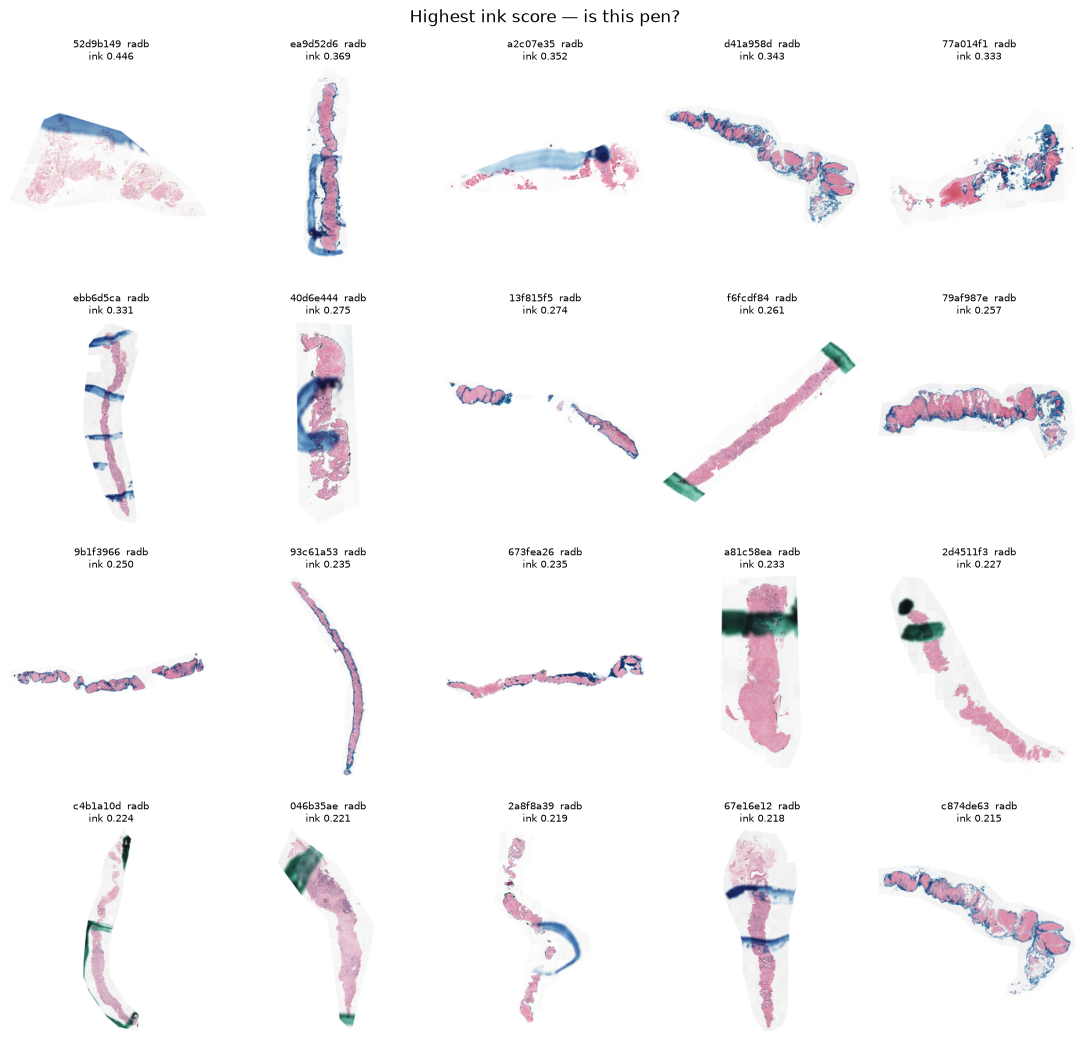

In [13]:
"""The 20 slides with the highest ink score, to check that the top of the
ranking really is pen marks. Each caption shows the ink score."""

inkiest = slide_inventory.nlargest(20, "ink_frac")
show_grid(
    inkiest,
    suptitle="Highest ink score — is this pen?",
    label=lambda r: f"{r.slide_id[:8]}  {r.provider[:4]}\nink {r.ink_frac:.3f}",
)
plt.show()

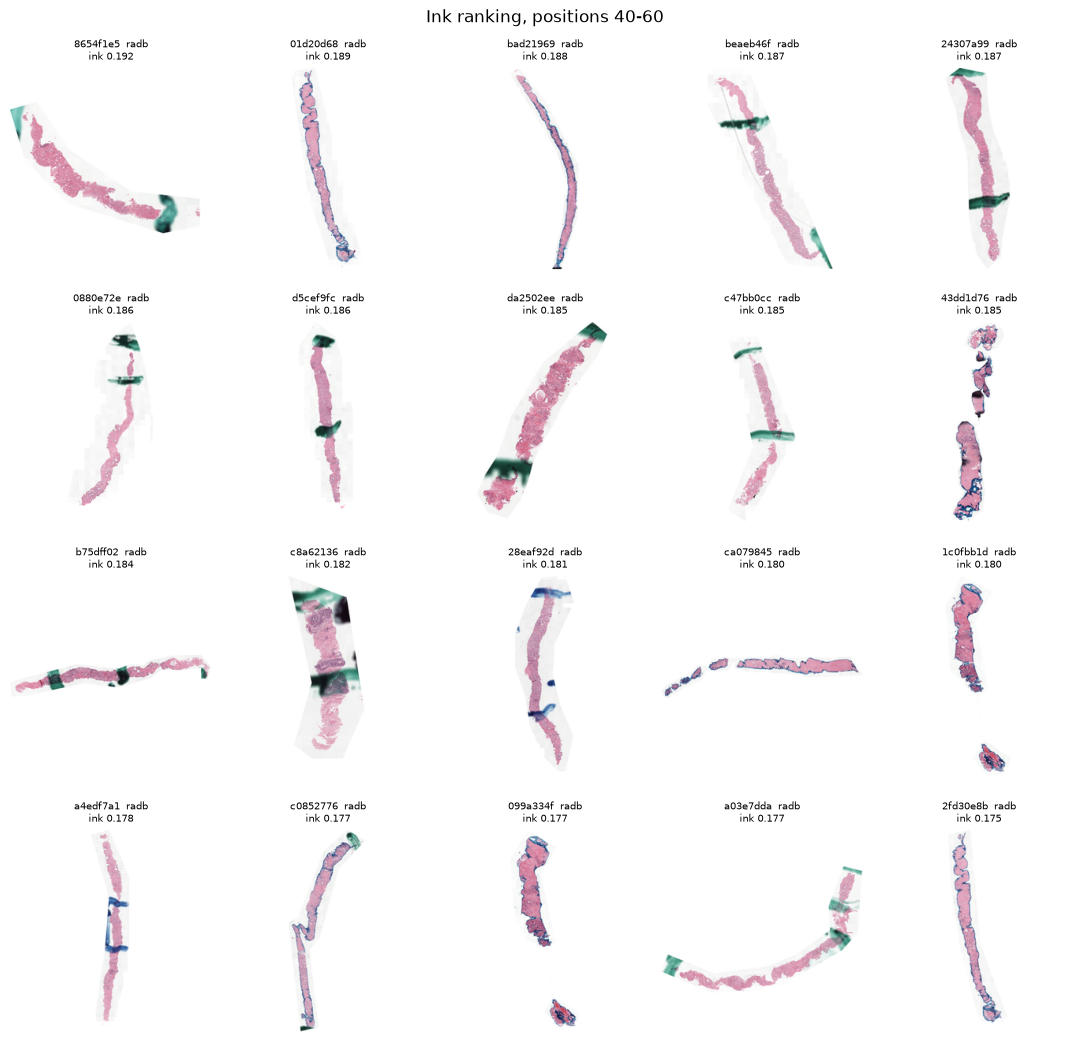

In [14]:
"""Walk down the ink ranking to find where the pen marks stop.

1. Sort every slide by ink score, highest first.
2. Take 20 slides starting at position START.
3. Draw them. Change START and re-run until the grid no longer shows ink; the
   ink score on the last grid that still did is the cutoff.
"""

START = 40
window = slide_inventory.sort_values("ink_frac", ascending=False).iloc[START : START + 20]
show_grid(
    window,
    suptitle=f"Ink ranking, positions {START}-{START + 20}",
    label=lambda r: f"{r.slide_id[:8]}  {r.provider[:4]}\nink {r.ink_frac:.3f}",
)
plt.show()

In [15]:
"""Count the pen-marked slides at the chosen cutoff.

INK_CUTOFF was chosen by walking the ranking above and looking: at 0.06 every
slide still shows a visible coloured mark, and below it the marks shrink to
specks at the biopsy tips that cover only a handful of pixels. See FINDINGS.md.

1. Keep the slides whose ink score is above the cutoff.
2. Print how many there are and what share of the dataset that is.
3. Print how they split by hospital, and by grade.
"""

INK_CUTOFF = 0.06

pen = slide_inventory[slide_inventory["ink_frac"] > INK_CUTOFF]
print(f"slides above cutoff: {len(pen)}  ({100 * len(pen) / len(slide_inventory):.1f}% of the dataset)")
print(pen["provider"].value_counts())
print(pen["isup_grade"].value_counts().sort_index())

slides above cutoff: 317  (3.0% of the dataset)
provider
radboud    317
Name: count, dtype: int64
isup_grade
0    26
1    83
2    55
3    72
4    42
5    39
Name: count, dtype: int64


### 3b. Faintly stained slides

The opposite failure. A slide whose stain barely took has low saturation
everywhere, and a tissue detector tuned on normal slides will decide it is
empty glass and return almost no tiles. These are the slides that set the floor
for the Stage 5 threshold.

Same method: rank by mean saturation, look at the bottom, find where genuinely
faint stops and merely-pale begins.

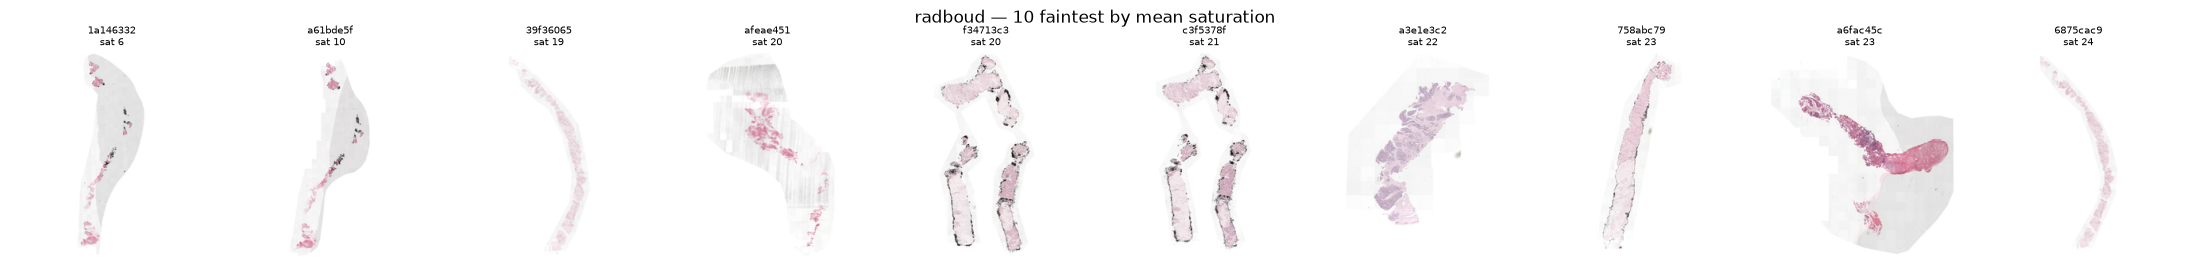

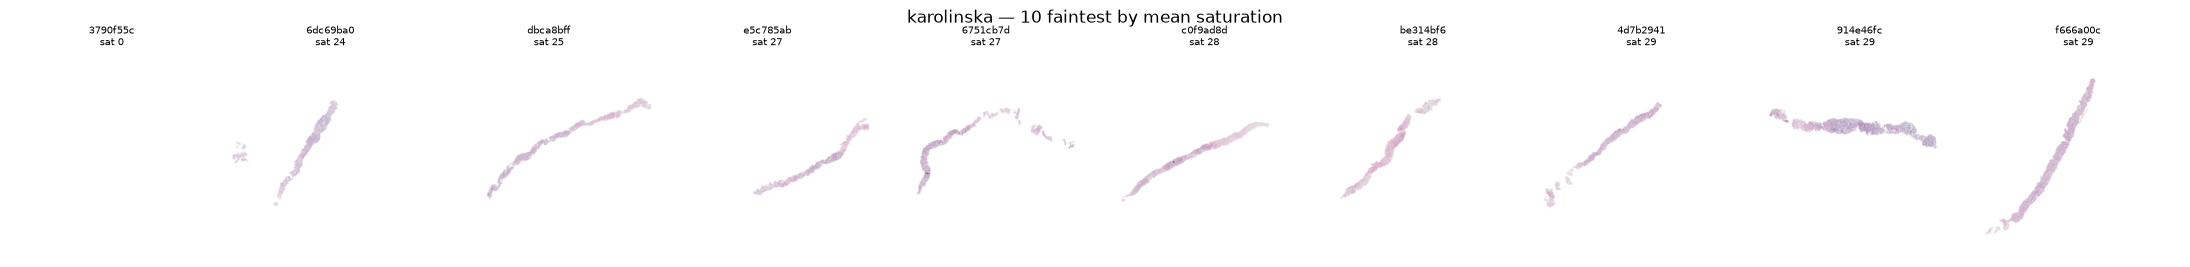

In [16]:
"""The 10 faintest slides from each hospital, by mean saturation.

Faintness is ranked within each hospital rather than across both, because the
two hospitals' stains differ in strength: Radboud's are paler overall, so a
combined ranking would be nearly all Radboud. Each caption shows the mean
saturation.
"""

for provider in ["radboud", "karolinska"]:
    rows = slide_inventory[slide_inventory["provider"] == provider].nsmallest(10, "saturation_mean")
    show_grid(
        rows,
        ncols=10,
        suptitle=f"{provider} — 10 faintest by mean saturation",
        label=lambda r: f"{r.slide_id[:8]}\nsat {r.saturation_mean:.0f}",
    )
plt.show()